## IMPORT NECESSARY DEPENDINCIES

In [ ]:
pip install selenium

In [ ]:
pip install webdriver-manager

In [ ]:
pip install httpx[http2]

In [ ]:
!pip install shap

In [ ]:
pip install category_encoders

In [ ]:
pip install lightgbm

In [ ]:
pip install optuna

## WEB SCRAPING AND DATA PREPROCESSING

In [1]:
import re
import json
from bs4 import BeautifulSoup
from html import unescape
from pathlib import Path

def load_html_from(path_or_url):
    p = Path(path_or_url)
    if p.exists():
        return p.read_text(encoding="utf-8", errors="ignore")
    else:
        import requests
        resp = requests.get(path_or_url, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        return resp.text

def extract_js_json(html, varname):
    patterns = [
        rf"{re.escape(varname)}\s*=\s*(\{{.*?\}});",
        rf"window\.{re.escape(varname)}\s*=\s*(\{{.*?\}});",
        rf"var\s+{re.escape(varname)}\s*=\s*(\{{.*?\}});"
    ]
    for pat in patterns:
        m = re.search(pat, html, flags=re.S)
        if m:
            js_text = m.group(1)
            try:
                return json.loads(js_text)
            except json.JSONDecodeError:
                cleaned = re.sub(r"(\r|\n)", " ", js_text)
                cleaned = re.sub(r",\s*}", "}", cleaned)
                cleaned = re.sub(r",\s*\]", "]", cleaned)
                try:
                    return json.loads(cleaned)
                except Exception:
                    return None
    return None

def clean_html_fragment(html_fragment):
    if not html_fragment:
        return ""
    un = unescape(html_fragment)
    return BeautifulSoup(un, "lxml").get_text(separator="\n", strip=True)

def find_value_from_properties(props, key_name):
    if not props:
        return None
    for p in props:
        if p.get("Key", "").strip().lower() == key_name.lower():
            return p.get("Value")
    return None

def find_tramer_and_damage_texts(soup):
    result = {"tramer": None, "damage_tab_text": None, "mentioned_parts": []}
    damage_tab = soup.select_one("#tab-damage-information")
    if damage_tab:
        txt = damage_tab.get_text(" ", strip=True)
        result["damage_tab_text"] = txt
        m = re.search(r"Tramer[^0-9€£$₺\d]*([\d\.\, ]+)\s*(TL|₺)?", txt, flags=re.I)
        if m:
            tramer_raw = m.group(1)
            tramer_val = re.sub(r"[^\d]", "", tramer_raw)
            try:
                result["tramer"] = int(tramer_val)
            except:
                result["tramer"] = tramer_raw.strip()
        parts_pattern = r"\b(sağ ön|sol ön|sağ arka|sol arka|ön|arka|kaput|tampon|çamurluk|kapı|tavan|bagaj|motor kapağı|sol|sağ)\b[^\.\n,;]{0,60}"
        found = re.findall(parts_pattern, txt, flags=re.I)
        result["mentioned_parts"] = list({f.strip().lower() for f in found if f})
    return result

def extract_all_from_html(html):
    soup = BeautifulSoup(html, "lxml")
    out = {}
    pd = extract_js_json(html, "productDetail")
    out["productDetail"] = pd
    cdo = extract_js_json(html, "collectDataObject")
    out["collectDataObject"] = cdo

    def find_in_tech(name):
        if not pd:
            return None
        for td in pd.get("TechnicalDetailSummary") or []:
            if td.get("Name") and name.lower() in td["Name"].lower():
                return td.get("Value")
        return None

    if pd:
        out["price"] = pd.get("Price")
        out["formatted_price"] = pd.get("FormattedPrice")
        out["description_html"] = pd.get("Description")
        out["description_text"] = clean_html_fragment(pd.get("Description"))
        out["mobile_phone_hidden"] = pd.get("MobilePhoneHidden")

        props = pd.get("Properties") or []
        props_map = {p.get("Key"): p.get("Value") for p in props}
        out["properties"] = props_map

        out["brand"] = pd.get("BrandName") or props_map.get("Marka")
        out["serial"] = pd.get("Serial") or props_map.get("Seri")
        out["model"] = find_value_from_properties(props, "Model") or props_map.get("Model")
        out["year"] = find_value_from_properties(props, "Yıl") or props_map.get("Yıl")
        out["km"] = find_value_from_properties(props, "Kilometre") or props_map.get("Kilometre")
        out["gear"] = find_value_from_properties(props, "Vites Tipi") or props_map.get("Vites Tipi")
        out["fuel"] = find_value_from_properties(props, "Yakıt Tipi") or props_map.get("Yakıt Tipi")
        out["body_type"] = find_value_from_properties(props, "Kasa Tipi") or props_map.get("Kasa Tipi")
        out["color"] = find_value_from_properties(props, "Renk") or props_map.get("Renk")
        out["damage_short"] = find_value_from_properties(props, "Boya-değişen") or props_map.get("Boya-değişen")
        out["engine_volume"] = props_map.get("Motor Hacmi") or find_in_tech("Motor Hacmi")
        out["engine_power"] = props_map.get("Motor Gücü") or find_in_tech("Motor Gücü")
        out["traction"] = props_map.get("Çekiş") or find_in_tech("Çekiş")
        # out["avg_fuel_consumption"] = props_map.get("Ort. Yakıt Tüketimi") or find_in_tech("Ortalama Yakıt Tüketimi")
        # out["fuel_tank"] = props_map.get("Yakıt Deposu") or find_in_tech("Yakıt Deposu")
        # out["class"] = props_map.get("Sınıfı") or find_in_tech("Sınıfı")
        #out["transmission"] = props_map.get("Şanzıman") or find_in_tech("Şanzıman")
        # out["avg_insurance"] = props_map.get("Ortalama Kasko") or pd.get("MotorInsurance")
        # out["avg_traffic_insurance"] = props_map.get("Ortalama Trafik Sigortası") or pd.get("TrafficInsurance")
        #out["torque"] = props_map.get("Torque") or find_in_tech("Torque")
        #out["cylinder"] = props_map.get("Silindir Sayısı") or find_in_tech("Silindir")
        # out["max_power"] = props_map.get("Maksimum Güç") or find_in_tech("Maksimum Güç")
        # #out["min_power"] = props_map.get("Minimum Güç") or find_in_tech("Minimum Güç")
        # out["acceleration"] = props_map.get("Hızlanma (0-100)") or find_in_tech("Hızlanma")
        # out["max_speed"] = props_map.get("Maksimum Hız") or find_in_tech("Maksimum Hız")
        #out["weight"] = props_map.get("Ağırlık") or find_in_tech("Ağırlık")
        #out["width"] = props_map.get("Genişlik") or find_in_tech("Genişlik")
        #out["length"] = props_map.get("Uzunluk") or find_in_tech("Uzunluk")
        #out["seat_count"] = props_map.get("Koltuk Sayısı") or find_in_tech("Koltuk Sayısı")
        #out["trunk_volume"] = props_map.get("Bagaj Hacmi") or find_in_tech("Bagaj Hacmi")

    elif cdo:
        out.update(cdo)
        out["price"] = cdo.get("Price")
        out["description_text"] = cdo.get("Description") or ""

    damage_info = find_tramer_and_damage_texts(soup)
    out.update(damage_info)

    desc = out.get("description_text", "")
    parts_mentioned = re.findall(
        r"(sağ ön çamurluk|sağ ön|sol ön|sağ arka|sol arka|bagaj kapağı|kaput|tampon|kapı|tavan|çamurluk|motor kaputu|kaport[aı])",
        desc,
        flags=re.I
    )
    out["description_mentioned_parts"] = list({p.lower() for p in parts_mentioned})

    return out

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from urllib.parse import urljoin, urlparse, parse_qs, urlencode
import time
import requests
from bs4 import BeautifulSoup

def parse_price(text):
    try:
        s = "".join([c for c in text if c.isdigit()])
        return int(s) if s else None
    except:
        return None

def extract_listings_from_html(html, base_url, min_price, max_price):
    soup = BeautifulSoup(html, "html.parser")
    rows = soup.select("tr.listing-list-item")
    results = []

    for r in rows:
        price_el = r.select_one(".listing-price")
        if not price_el:
            continue
        price_val = parse_price(price_el.get_text(strip=True))
        if price_val is None or not (min_price <= price_val <= max_price):
            continue

        a = r.select_one("a.link-overlay, a.smallest-text-minus, a[href^='/ilan/']")
        if a and a.get("href"):
            full = urljoin(base_url, a["href"])
            results.append(full)
    return results


def get_listing_links(start_url, max_pages=2, headless=True, min_price=800000, max_price=1200000, take=50):
    print(min_price)
    print(max_price)
    options = webdriver.ChromeOptions()
    if headless:
        options.add_argument("--headless=new")
        options.add_argument("--disable-gpu")
    options.add_argument("--blink-settings=imagesEnabled=false")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--disable-extensions")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

    collected = set()
    try:
        for page_idx in range(1, max_pages + 1):
            url = f"{start_url}?currency=TL&maxPrice={max_price}&minPrice={min_price}&take={take}&page={page_idx}&days=1"
            try:
                r = requests.get(url, timeout=8, headers={"User-Agent": "Mozilla/5.0"})
                if r.status_code == 200:
                    links = extract_listings_from_html(r.text, start_url, min_price, max_price)
                    collected.update(links)
                    print(f"[Requests] {page_idx}. sayfa -> {len(links)} ilan bulundu")
                    print(len(collected))
                    continue
            except:
                pass
                
            driver.get(url)
            time.sleep(1.5)
            html = driver.page_source
            links = extract_listings_from_html(html, start_url, min_price, max_price)
            collected.update(links)
            print(f"[Selenium] {page_idx}. sayfa -> {len(links)} ilan bulundu")

    finally:
        driver.quit()

    return list(collected)


if __name__ == "__main__":
    start = "https://www.arabam.com/ikinci-el/otomobil"
    links = get_listing_links(start, max_pages=53, headless=True, min_price=100000, max_price=1650000, take=50)
    print(f"\nTOPLAM {len(links)} link bulundu")

In [ ]:
import httpx
from urllib.parse import urljoin
from typing import List
import nest_asyncio, asyncio
nest_asyncio.apply()

async def fetch_and_parse(client: httpx.AsyncClient, url: str, sem: asyncio.Semaphore,
                          max_retries: int = 3, timeout: float = 15.0):
    for attempt in range(1, max_retries+1):
        try:
            async with sem:
                resp = await client.get(url, timeout=timeout)
            resp.raise_for_status()
            html = resp.text
            data = await asyncio.to_thread(extract_all_from_html, html)
            data["source_url"] = url
            return data
        except Exception as e:
            if attempt == max_retries:
                print(f"[FAILED] {url} -> {e}")
                return None
            await asyncio.sleep(0.5 * attempt)

async def scrape_links_async(links: List[str], concurrency: int = 20):
    limits = httpx.Limits(max_keepalive_connections=concurrency, max_connections=concurrency*2)
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; MyScraper/1.0)",
        "Accept-Encoding": "gzip, deflate, br"
    }
    sem = asyncio.Semaphore(concurrency)
    async with httpx.AsyncClient(limits=limits, headers=headers, http2=True) as client:
        tasks = [asyncio.create_task(fetch_and_parse(client, url, sem)) for url in links]
        results = await asyncio.gather(*tasks)
    return [r for r in results if r is not None]

if __name__ == "__main__":
    listings = await scrape_links_async(links, concurrency=50)
    print(len(listings))

In [ ]:
import re
import math
import pandas as pd
import numpy as np

def parse_numeric_value(x):
    if x is None:
        return None
    if isinstance(x, (int, float)):
        return x

    s = str(x).lower().strip()
    s = s.replace(",", ".")
    m = re.search(r"(\d+(\.\d+)?)", s)
    if not m:
        return None
    val = float(m.group(1))
    
    if "cc" in s:
        return int(val)
    if "lt" in s or "l " in s or s.endswith("l"):
        return float(val)
    if "sn" in s or "saniye" in s:
        return float(val)
    if "km/s" in s or "kmh" in s or "km/h" in s:
        return int(val)
    if "kg" in s:
        return int(val)
    if "mm" in s:
        return int(val)
    if "kw" in s or "hp" in s or "bg" in s:
        return int(val)
    if "silindir" in s:
        return int(val)
    return val


def parse_price(x):
    try:
        return int(x)
    except:
    
        if isinstance(x, str):
            s = re.sub(r"[^\d]", "", x)
            return int(s) if s else None
    return None

def parse_km(km_str):
    if km_str is None: return None
    if isinstance(km_str, (int,float)): return int(km_str)
    s = str(km_str)
    m = re.search(r"(\d[\d\.\, ]+)", s)
    if m:
        num = re.sub(r"[^\d]", "", m.group(1))
        return int(num) if num else None
    m2 = re.search(r"(\d+)", s)
    return int(m2.group(1)) if m2 else None

def parse_year(y):
    try:
        return int(str(y))
    except:
        return None

def parse_tramer(t):
    if t is None: return None
    try:
        return int(t)
    except:
        if isinstance(t,str):
            s = re.sub(r"[^\d]", "", t)
            return int(s) if s else None
    return None

def parse_damage_short(s):
    if not s: return 0
    m = re.search(r"(\d+)\s*değiş", str(s))
    if m:
        return int(m.group(1))
    return 0

def parse_city(full_address):
    if not full_address: return None
    parts = [p.strip() for p in full_address.split("/") if p.strip()]
    return parts[0].title() if parts else None

def extract_desc_flags(desc):
    d = (desc or "").lower()
    return {
        "first_owner_flag": int("ilk sahib" in d or "ilk sahibi" in d),
        "ppf_flag": int("ppf" in d or "kaplama" in d),
        "guarantee_flag": int("garanti" in d or "garantisi" in d),
        "no_plate_flag": int("plaka verilmeyecek" in d or "plaka verilmeyecektir" in d),
    }

PART_MAP = {
    "sağ ön çamurluk": "right_front_fender",
    "sol ön çamurluk": "left_front_fender",
    "sağ arka çamurluk": "right_rear_fender",
    "sol arka çamurluk": "left_rear_fender",
    "sağ ön kapı": "right_front_door",
    "sol ön kapı": "left_front_door",
    "sağ arka kapı": "right_rear_door",
    "sol arka kapı": "left_rear_door",
    "ön tampon": "front_bumper",
    "arka tampon": "rear_bumper",
    "motor kaputu": "hood",
    "tavan": "roof",
    "arka kaput": "trunk_lid",
    "çamurluk": "fender_generic",
    "kapı": "door_generic",
}

def extract_expertise_flags(pd):
    """
    pd: productDetail dict (may be None)
    returns dict of part flags + counts like num_changed_parts, num_painted_parts, num_sectional_painted_parts
    """
    flags = {}

    for part in PART_MAP.values():
        flags[f"changed_{part}"] = 0
        flags[f"painted_{part}"] = 0
        flags[f"sectional_painted_{part}"] = 0

    num_changed = 0
    num_painted = 0
    num_sectional_painted = 0
    has_expertise = False

    expertise = pd.get("Expertise") if pd else None
    if expertise and isinstance(expertise, dict):
        details = expertise.get("ExpertiseDetails") or []
        has_expertise = True if details else False

        for item in details:
            name = (item.get("Name") or "").lower().strip()
            val_text = (item.get("ValueText") or "").lower().strip()
            val_code = str(item.get("Value")).lower().strip() if item.get("Value") else ""
            
            for k, col in PART_MAP.items():
                if k in name:
                    # değişmiş
                    if val_text in ("changed", "değişmiş"):
                        flags[f"changed_{col}"] = 1
                        num_changed += 1
                    # boyalı
                    elif val_text in ("painted", "boyanmış"):
                        flags[f"painted_{col}"] = 1
                        num_painted += 1
                    # lokal boyalı / sectional
                    elif val_text in ("sectionalpainted", "lokal boyanmış"):
                        flags[f"sectional_painted_{col}"] = 1
                        num_sectional_painted += 1

    flags["has_expertise"] = int(has_expertise)
    return flags

def normalize_listing(listing: dict):
    """
    Input: one raw listing dict (like the one you pasted)
    Output: flattened dict with only ML-relevant features
    """
    out = {}
    
    out["price"] = parse_price(listing.get("price") or 
                               listing.get("Price") or 
                               listing.get("FormattedPrice"))
    if out["price"] is None and listing.get("productDetail"):
        out["price"] = parse_price(listing["productDetail"].get("Price"))

    year = listing.get("year") or (listing.get("properties") or {}).get("Yıl") or (listing.get("productDetail") or {}).get("Year")
    out["km"] = parse_km(listing.get("km") or (listing.get("properties") or {}).get("Kilometre") or (listing.get("productDetail") or {}).get("CollectData",{}).get("Km"))
    out["age"] = max(0, 2025 - int(year)) if int(year) else None

    props = listing.get("properties") or {}
    pd = listing.get("productDetail") or {}

    out["brand"] = listing.get("brand") or props.get("Marka")
    out["serial"] = listing.get("serial") or props.get("Seri")
    out["model"] = listing.get("model") or props.get("Model")
    out["fuel"] = listing.get("fuel") or props.get("Yakıt Tipi")
    out["gear"] = listing.get("gear") or props.get("Vites Tipi")
    out["body_type"] = listing.get("body_type") or props.get("Kasa Tipi")
    out["color"] = listing.get("color") or props.get("Renk")
    #out["owner"] = props.get("Kimden") or pd.get("Member",{}).get("MemberType",{}).get("Name") or pd.get("Member",{}).get("MemberType",{}).get("Description")
    #out["has_photo"] = int(bool(pd.get("HasPhoto") or listing.get("HasPhoto")))
    out["has_equipment"] = int(bool(pd.get("HasEquipment") or listing.get("HasEquipment")))
    #out["is_first_owner"] = int(bool(pd.get("IsFirstOwner") or listing.get("IsFirstOwner")))
    #out["is_like_new"] = int(bool(pd.get("IsLikeNew") or listing.get("IsLikeNew")))
    out["suitable_for_credit"] = int(bool(pd.get("SuitableForCredit") or listing.get("SuitableForCredit")))
    #out["city"] = parse_city(pd.get("FullAddress") or listing.get("FullAddress"))

    try:
        out["tramer"] = parse_tramer(listing.get("tramer") or pd.get("DamageInfo",{}).get("DamagePrice"))
    except:
        out["tramer"] = 0
    out["damage_short_count"] = parse_damage_short(listing.get("damage_short") or props.get("Boya-değişen"))

    desc_text = listing.get("description_text") or pd.get("Description")
    out["description_text"] = desc_text
    out.update(extract_desc_flags(desc_text))

    parts_flags = extract_expertise_flags(pd)
    out.update(parts_flags)

    out["engine_volume"] = parse_numeric_value(props.get("Motor Hacmi"))
    out["engine_power"] = parse_numeric_value(props.get("Motor Gücü"))
    out["traction"] = props.get("Çekiş")  # genelde "4x2", "4x4" string kalacak
    # out["avg_fuel_consumption"] = parse_numeric_value(props.get("Ort. Yakıt Tüketimi") or _find_tech_detail(pd, "Ortalama Yakıt Tüketimi"))
    # out["fuel_tank"] = parse_numeric_value(props.get("Yakıt Deposu"))
    # out["class"] = props.get("Sınıfı") or pd.get("VehicleClass")
    # #out["transmission"] = props.get("Şanzıman") or pd.get("Gear")
    # out["avg_insurance"] = parse_numeric_value(pd.get("MotorInsurance"))
    # out["avg_traffic_insurance"] = parse_numeric_value(pd.get("TrafficInsurance"))
    # #out["torque"] = parse_numeric_value(props.get("Tork"))
    # #out["cylinder"] = parse_numeric_value(props.get("Silindir"))
    # out["max_power"] = parse_numeric_value(props.get("Maksimum Güç") or _find_tech_detail(pd, "Maksimum Güç"))
    # #out["min_power"] = parse_numeric_value(props.get("Minimum Güç"))
    # out["acceleration"] = parse_numeric_value(props.get("Hızlanma") or _find_tech_detail(pd, "Hızlanma (0-100)"))
    # out["max_speed"] = parse_numeric_value(props.get("Maksimum Hız") or _find_tech_detail(pd, "Maksimum Hız"))
    #out["weight"] = parse_numeric_value(props.get("Ağırlık"))
    #out["width"] = parse_numeric_value(props.get("Genişlik"))
    #out["length"] = parse_numeric_value(props.get("Uzunluk"))
    #out["seat_count"] = parse_numeric_value(props.get("Koltuk Sayısı"))
    #out["trunk_volume"] = parse_numeric_value(props.get("Bagaj Hacmi"))

    return out

def _find_tech_detail(pd, name):
    for td in (pd.get("TechnicalDetailSummary") or []):
        if td.get("Name") and name.lower() in td["Name"].lower():
            return td.get("Value")
    return None


if __name__ == "__main__":
    import json

    normalized = [normalize_listing(l) for l in listings]
    df = pd.DataFrame(normalized)

    numeric_cols = ["price","km","age","tramer"]
    cat_cols = ["brand","model","serial","fuel","gear","body_type","color","city","owner"]

    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    for c in numeric_cols:
        if c in df.columns:
            df[c].fillna(df[c].median(), inplace=True)

    for c in cat_cols:
        if c in df.columns:
            df[c].fillna("unknown", inplace=True)

In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [146]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

turkish_stopwords = stopwords.words("turkish")

In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

target = "price"
text_feature = "description_text"

for col in ["brand", "model", "serial"]:
    mean_map = df.groupby(col)[target].mean()
    df[col + "_enc"] = df[col].map(mean_map)

df = df.drop(columns=["brand", "model", "serial"])

target_enc_features = ["brand_enc", "model_enc", "serial_enc"]

num_features = [
    "age","km","tramer","damage_short_count",
    "engine_volume","engine_power"
] + target_enc_features

cat_features = [
    "fuel","gear","body_type","color","traction"
]

binary_features = [
    col for col in df.columns
    if col not in num_features + cat_features + [text_feature, target, "price_log"]
    and df[col].dropna().isin([0,1]).all()
]

In [173]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', binary_features),
        ('text', TfidfVectorizer(max_features=180, ngram_range=(1,4), stop_words=turkish_stopwords), text_feature)
    ]
)

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import r2_score

def objective(trial):
    # LightGBM parametreleri
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # TF-IDF parametreleri
    max_features = trial.suggest_int("tfidf_max_features", 10, 200, step=10)
    ngram_max = trial.suggest_int("tfidf_ngram_max", 1, 5)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
            ('bin', 'passthrough', binary_features),
            ('text', TfidfVectorizer(
                max_features=max_features,
                ngram_range=(1, ngram_max),
                min_df=2,
                max_df=0.95,
                stop_words=turkish_stopwords
            ), text_feature)
        ]
    )

    regressor = lgb.LGBMRegressor(**params)

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return r2_score(y_test, preds)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

In [172]:
print("Best R2 Score:", study.best_value)
print("Best Params:", study.best_trial.params)

Best R2 Score: 0.9531150967814229
Best Params: {'n_estimators': 1132, 'learning_rate': 0.03525065750237316, 'num_leaves': 279, 'max_depth': 14, 'subsample': 0.69197316147473, 'colsample_bytree': 0.5568560968430666, 'tfidf_max_features': 180, 'tfidf_ngram_max': 4}


In [174]:
regressor = lgb.LGBMRegressor(
    n_estimators=1132,
    learning_rate=0.03551505173175971,
    num_leaves=279,
    subsample=0.6941199024331827,
    colsample_bytree=0.5595376141846347,
    random_state=42,
    max_depth=14
)

from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", regressor)
])

In [175]:
X = df[num_features + cat_features + binary_features + [text_feature]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [176]:
nan_cols = X_test.columns[X_train.isna().any()].tolist()
print("NaN içeren kolonlar:", nan_cols)

NaN içeren kolonlar: ['engine_volume', 'engine_power', 'traction']


In [177]:
nan_summary = X_test.isna().sum()
nan_summary = nan_summary[nan_summary > 0]
print("NaN özet tablosu:\n", nan_summary)

NaN özet tablosu:
 engine_volume    6
engine_power     4
traction         4
dtype: int64


In [178]:
X_train = X_train.dropna()
X_test = X_test.dropna()

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

In [ ]:
model.fit(X_train, y_train)

In [180]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MAE: 63636.18580667057
R2 : 0.9525117045330601


C:\Users\kagan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [181]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train R²: {r2_train:.3f}, Test R²: {r2_test:.3f}")

C:\Users\kagan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train R²: 1.000, Test R²: 0.953


C:\Users\kagan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [182]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 63636.19


In [183]:
from sklearn.metrics import median_absolute_error
median_error = median_absolute_error(y_test, y_pred)
print(f"Median AE: {median_error:.2f}")

Median AE: 45767.92


In [184]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 10.27%


In [185]:
errors = y_test - y_pred
percentage_errors = np.abs(errors / y_test) * 100
median_pct_error = percentage_errors.median()

print(f"Medyan Hata (%): {median_pct_error:.2f}%")

Medyan Hata (%): 6.95%


In [186]:
percentage_errors.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

count    613.000000
mean      10.274474
std       16.274312
min        0.016940
10%        1.243236
25%        3.140094
50%        6.950083
75%       12.743610
90%       20.968195
max      317.932462
Name: price, dtype: float64

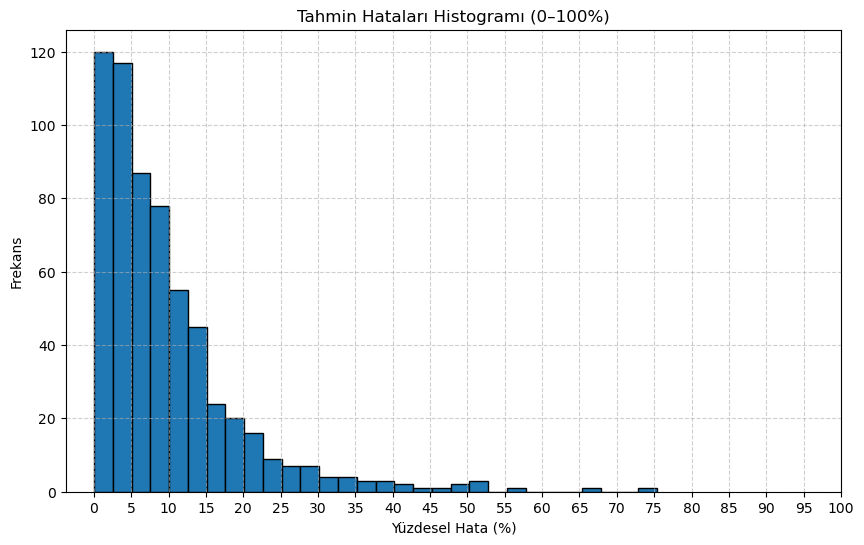

In [187]:
import matplotlib.pyplot as plt

filtered_errors = percentage_errors[(percentage_errors >= 0) & (percentage_errors <= 100)]

plt.figure(figsize=(10,6))
plt.hist(filtered_errors, bins=30, edgecolor="black")
plt.xlabel("Yüzdesel Hata (%)")
plt.ylabel("Frekans")
plt.title("Tahmin Hataları Histogramı (0–100%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(np.arange(0, 101, 5))

plt.show()

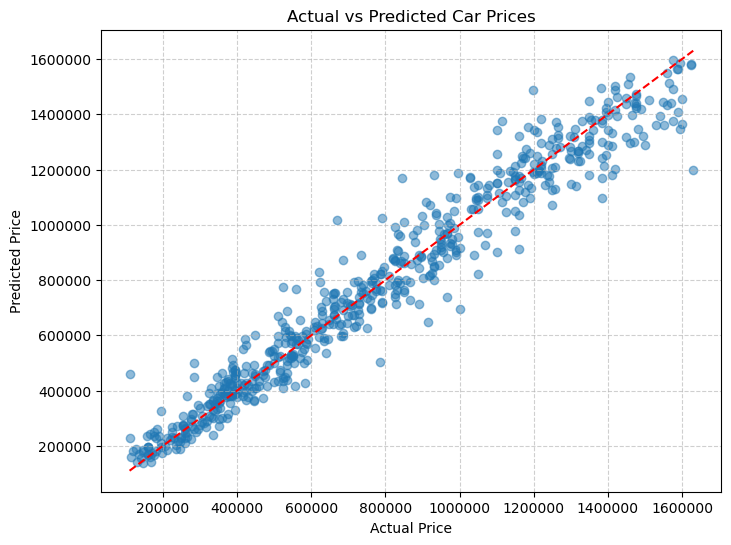

In [188]:
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='both', style='plain')

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

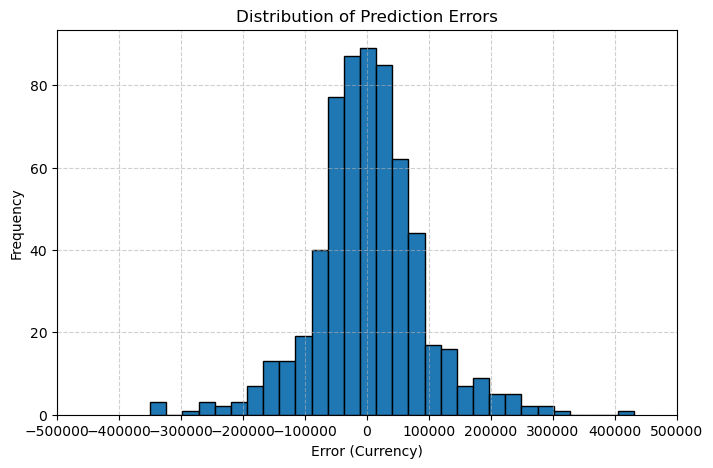

In [189]:
from matplotlib.ticker import ScalarFormatter

errors = y_test - y_pred
filtered_errors = errors[(errors >= -500000) & (errors <= 500000)]

plt.figure(figsize=(8,5))
plt.hist(filtered_errors, bins=30, edgecolor="black")
plt.xlabel("Error (Currency)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().ticklabel_format(axis='x', style='plain')

plt.xticks(np.arange(-500000, 500001, 100000))

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [190]:
percentage_errors = np.abs(errors / y_test) * 100

top_pct_error_idx = percentage_errors.argsort()[::-1]

top_pct_errors = pd.DataFrame({
    'Gerçek Fiyat': y_test,
    'Tahmin': y_pred,
    'Hata (TL)': errors,
    'Hata (%)': percentage_errors
}).iloc[top_pct_error_idx]

top_pct_errors['Gerçek Fiyat'] = top_pct_errors['Gerçek Fiyat'].round(0).astype(int)
top_pct_errors['Tahmin'] = top_pct_errors['Tahmin'].round(0).astype(int)
top_pct_errors['Hata (TL)'] = top_pct_errors['Hata (TL)'].round(0).astype(int)
top_pct_errors['Hata (%)'] = top_pct_errors['Hata (%)'].round(0).astype(int)

print("En yüksek yüzde hatalar:")
print(top_pct_errors.head(10))

En yüksek yüzde hatalar:
      Gerçek Fiyat   Tahmin  Hata (TL)  Hata (%)
1392        110000   459726    -349726       318
876         110000   226896    -116896       106
1372        285000   499830    -214830        75
1561        195000   325792    -130792        67
1377        285000   449667    -164667        58
579         119000   180909     -61909        52
2405        670000  1016125    -346125        52
1669        157000   237441     -80441        51
2173        127500   189622     -62122        49
723         525000   775760    -250760        48


In [191]:
remaining_pct_errors = top_pct_errors['Hata (%)'].iloc[10:]
mean_pct_error_excl_top10 = remaining_pct_errors.mean()
print(f"\nEn büyük 10 hata çıkarıldıktan sonra ortalama Hata (%): {mean_pct_error_excl_top10:.2f}%")


En büyük 10 hata çıkarıldıktan sonra ortalama Hata (%): 8.99%


In [192]:
percentage_errors = np.abs(errors / y_test) * 100

top_abs_error_idx = np.abs(errors).argsort()[::-1]

top_abs_errors = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred,
    'Error (TL)': errors,
    'Error (%)': percentage_errors
}).iloc[top_abs_error_idx]

top_abs_errors['Actual Price'] = top_abs_errors['Actual Price'].round(0).astype(int)
top_abs_errors['Predicted Price'] = top_abs_errors['Predicted Price'].round(0).astype(int)
top_abs_errors['Error (TL)'] = top_abs_errors['Error (TL)'].round(0).astype(int)
top_abs_errors['Error (%)'] = top_abs_errors['Error (%)'].round(0).astype(int)

print("En büyük mutlak hatalar:")
print(top_abs_errors.head(10))

remaining_errors = top_abs_errors.iloc[10:]
mean_abs_pct_error_excl_top10 = remaining_errors['Error (%)'].abs().mean()
mean_abs_error_excl_top10 = remaining_errors['Error (TL)'].abs().mean()

print(f"En büyük 10 hata çıkarıldıktan sonra ortalama Mutlak Hata (TL): {mean_abs_error_excl_top10:.0f} TL")

En büyük mutlak hatalar:
      Actual Price  Predicted Price  Error (TL)  Error (%)
1516       1630000          1198719      431281         26
1392        110000           459726     -349726        318
2405        670000          1016125     -346125         52
2368        845000          1169103     -324103         38
304        1000000           695907      304093         30
947        1385000          1096875      288125         21
989        1199000          1486311     -287311         24
2365        785000           504139      280861         36
43          915000           648819      266181         29
2182       1115000          1376466     -261466         23
En büyük 10 hata çıkarıldıktan sonra ortalama Mutlak Hata (TL): 59485 TL


In [193]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_

importances_pct = 100 * importances / np.sum(importances)

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
    "importance_pct": importances_pct
})

def extract_group(name):
    if name.startswith("num__"):
        return name.replace("num__", "")
    elif name.startswith("cat__"):
        return name.replace("cat__", "").split("_")[0]
    elif name.startswith("bin__"):
        return "binary"
    elif name.startswith("text__"):
        return "text"
    else:
        return "other"

feat_imp["group"] = feat_imp["feature"].apply(extract_group)
grouped_importance = feat_imp.groupby("group")["importance_pct"].sum().sort_values(ascending=False)

print(grouped_importance)

group
text                  56.329838
km                     7.001238
model_enc              6.912496
binary                 4.775694
serial_enc             4.378693
engine_power           4.226898
age                    3.794867
engine_volume          3.131641
brand_enc              3.024217
color                  1.384835
body                   1.331123
fuel                   1.263399
gear                   0.978492
damage_short_count     0.719273
tramer                 0.429696
traction               0.317601
Name: importance_pct, dtype: float64


In [194]:
import shap
import numpy as np
import pandas as pd

regressor = model.named_steps['regressor']
preprocessor = model.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)

if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = X_test_transformed.astype(float)

explainer = shap.TreeExplainer(regressor)

shap_values = explainer.shap_values(X_test_transformed)

feature_names = preprocessor.get_feature_names_out()

text_cols = [i for i, name in enumerate(feature_names) if name.startswith("text__")]

i = 0
text_effect = np.abs(shap_values[i, text_cols]).sum()
print(f"İlan açıklamasının tahmine etkisi: {text_effect:.2f} TL")

İlan açıklamasının tahmine etkisi: 98555.16 TL


In [195]:
text_effects = []

for i in range(X_test.shape[0]):
    effect = shap_values[i, text_cols].sum()
    text_effects.append(effect)

min_effect = min(text_effects)
max_effect = max(text_effects)

print(f"Metnin tahmine en düşük etkisi: {min_effect:.2f} TL")
print(f"Metnin tahmine en yüksek etkisi: {max_effect:.2f} TL")

Metnin tahmine en düşük etkisi: -86405.57 TL
Metnin tahmine en yüksek etkisi: 82101.23 TL


In [196]:
text_feature_names = [feature_names[j] for j in text_cols]

total_text_shap = np.abs(shap_values[:, text_cols]).sum(axis=0)

df_text_shap = pd.DataFrame({
    "token": text_feature_names,
    "total_shap": total_text_shap
})


df_text_shap = df_text_shap[df_text_shap["token"].str.count(" ") >= 2]

df_text_shap = df_text_shap.sort_values("total_shap", ascending=False)
print(df_text_shap.head(20))

                 token    total_shap
42  text__di reksi yon  56384.453779
40     text__di ji tal  36947.598100
91     text__li rsi ni  23017.991651


In [198]:
import re
import pandas as pd
import numpy as np

keywords = [
    "ağır hasarlıdır", "ağır hasar", "hasar kaydı", "hasar kaydı var",
    "tramer kaydı mevcuttur", "tramer kaydı vardır", "tramerlidir",
    "kaza kaydı", "pert kayıtlı", "ağır kazalı", "kaza raporu mevcut"
]
pattern = "|".join([re.escape(k) for k in keywords])

mask = (X_test["tramer"] == 0) & X_test["description_text"].str.contains(pattern, case=False, na=False)
filtered_idx = X_test[mask].index   # bunlar df index’i

print(f"{len(filtered_idx)} ilan bulundu")

filtered_positions = [X_test.index.get_loc(idx) for idx in filtered_idx]

text_effects_filtered = []
for pos, idx in zip(filtered_positions, filtered_idx):
    effect = shap_values[pos, text_cols].sum()   # yönlü etki
    preview = X_test.loc[idx, "description_text"][:150]
    text_effects_filtered.append((idx, effect, preview))

df_text_effects = pd.DataFrame(text_effects_filtered, columns=["index", "text_effect", "desc_preview"])

print("\n--- En Çok Düşürenler ---")
print(df_text_effects.sort_values("text_effect").head(10))

print("\n--- En Çok Artıranlar ---")
print(df_text_effects.sort_values("text_effect", ascending=False).head(10))

150 ilan bulundu

--- En Çok Düşürenler ---
     index   text_effect                                       desc_preview
26    1261 -61648.272475  2016 MODEL\nSUZUKİ BALENO 1.2 GL\nARACIMIZIN Ö...
109   2035 -60034.440401  2019-20 TOYOTA COROLLA\n1.6VİSION OTOMATİK\n58...
8      637 -49961.272256  ARACIMIZDA;\n4 PARÇA BOYA MEVCUT\nHASAR KAYDI ...
73    1477 -48848.577931  VW PASSAT\n1.6TDİ TRENDLİNE 105HP\n2013\n272.0...
63     708 -47318.153728  ARACIMIZ 2018 ÇIKIŞLI 1.0 TSI MOTOR HIGHLİNE P...
57     822 -46324.002429  CRT MOTORS\nKREDİ KARTINA 12 TAKSİT İMKANIMIZ ...
41     805 -44069.623995  SF MOTORS\n2013 1.5 dCi\nKM:238000\nRENAULT FL...
146    794 -39734.981930  Sol iki kapı boyalı harici hatasız\nHasar kayd...
89    2263 -37324.677812  2015 MODEL\n176.000 KM\nAUDI A3 1.6 TDI AMBİTİ...
118   1004 -34882.349876  2018 MODEL NİSSAN MİCRA MATCH​ 1.2\nEKSPERTİZ\...

--- En Çok Artıranlar ---
     index   text_effect                                       desc_preview
66     947  45828